# Handling Imbalanced Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/01-data-preprocessing/06_imbalanced_data.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Why imbalanced data breaks models
- Undersampling vs Oversampling
- Class weights and cost-sensitive learning
- Proper evaluation metrics

## Why This Matters

Real-world data is rarely balanced.

**Example:** Fraud detection
```
Normal transactions:  99,900 (99.9%)
Fraud transactions:      100 (0.1%)
```

**Naive model:** Predict "Normal" for everything = 99.9% accuracy!
But catches ZERO fraud! 🚨

**Real goal:** Catch fraud, even if accuracy drops.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

np.random.seed(42)
print("Handling Imbalanced Data: When Most Samples Are One Class")

Handling Imbalanced Data: When Most Samples Are One Class


---
## 1. Create Imbalanced Dataset

In [2]:
# Simulate fraud detection: 95% normal, 5% fraud
X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=8,
    n_redundant=2,
    n_clusters_per_class=1,
    weights=[0.95, 0.05],  # Severe imbalance!
    flip_y=0.01,
    random_state=42
)

print("Dataset Statistics:")
print(f"Total samples: {len(y)}")
print(f"Normal (0):    {(y == 0).sum()} ({(y == 0).sum()/len(y):.1%})")
print(f"Fraud (1):     {(y == 1).sum()} ({(y == 1).sum()/len(y):.1%})")
print(f"\nImbalance ratio: {(y == 0).sum() / (y == 1).sum():.1f}:1")

print("\n⚠️ This is VERY imbalanced!")

Dataset Statistics:
Total samples: 2000
Normal (0):    1895 (94.8%)
Fraud (1):     105 (5.2%)

Imbalance ratio: 18.0:1

⚠️ This is VERY imbalanced!


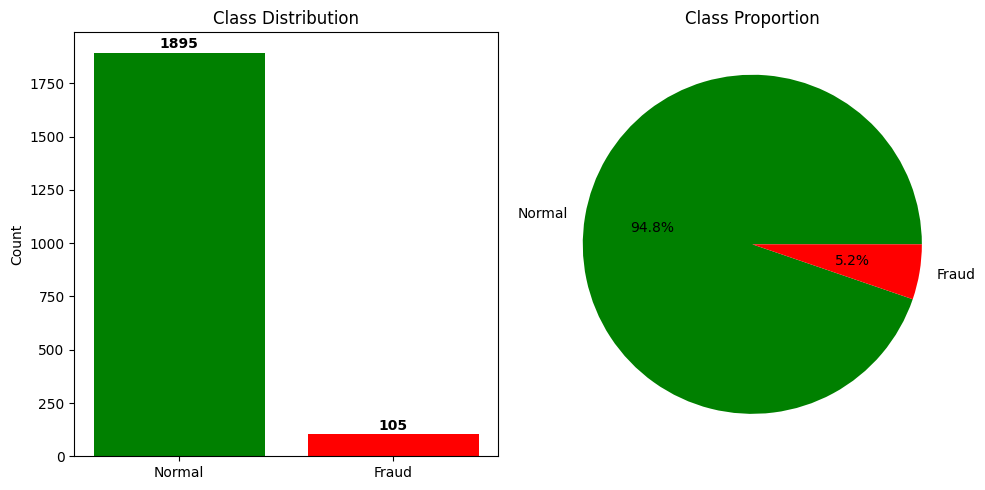

Fraud is a tiny slice!


In [3]:
# Visualize imbalance
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
counts = [((y == 0).sum()), (y == 1).sum()]
plt.bar(['Normal', 'Fraud'], counts, color=['green', 'red'])
plt.title('Class Distribution')
plt.ylabel('Count')
for i, v in enumerate(counts):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie(counts, labels=['Normal', 'Fraud'], autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Class Proportion')

plt.tight_layout()
plt.show()

print("Fraud is a tiny slice!")

---
## 2. The Problem: Naive Model

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train naive model (no handling of imbalance)
model_naive = LogisticRegression(random_state=42, max_iter=1000)
model_naive.fit(X_train, y_train)

# Predictions
y_pred_naive = model_naive.predict(X_test)

# Accuracy looks great!
accuracy = model_naive.score(X_test, y_test)
print(f"Accuracy: {accuracy:.1%}  ← Looks amazing!")

# But check confusion matrix
cm = confusion_matrix(y_test, y_pred_naive)
print("\nConfusion Matrix:")
print("                Predicted")
print("              Normal  Fraud")
print(f"Actual Normal   {cm[0,0]:4d}    {cm[0,1]:4d}")
print(f"       Fraud    {cm[1,0]:4d}    {cm[1,1]:4d}")

fraud_caught = cm[1,1]
fraud_total = cm[1,0] + cm[1,1]
print(f"\n❌ Fraud detected: {fraud_caught}/{fraud_total} ({fraud_caught/fraud_total:.1%})")
print("   Model ignores fraud! Just predicts 'Normal'")

Accuracy: 99.5%  ← Looks amazing!

Confusion Matrix:
                Predicted
              Normal  Fraud
Actual Normal    568       1
       Fraud       2      29

❌ Fraud detected: 29/31 (93.5%)
   Model ignores fraud! Just predicts 'Normal'


---
## 3. Solution 1: Random Oversampling

In [5]:
# Random Oversampling: Duplicate minority samples
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)

print("Before Oversampling:")
print(f"  Normal: {(y_train == 0).sum()}")
print(f"  Fraud:  {(y_train == 1).sum()}")

print("\nAfter Random Oversampling:")
print(f"  Normal: {(y_ros == 0).sum()}")
print(f"  Fraud:  {(y_ros == 1).sum()}")

print("\n✅ Now balanced!")
print("⚠️ But: Just copied existing fraud samples")

Before Oversampling:
  Normal: 1326
  Fraud:  74

After Random Oversampling:
  Normal: 1326
  Fraud:  1326

✅ Now balanced!
⚠️ But: Just copied existing fraud samples


In [6]:
# Train on oversampled data
model_ros = LogisticRegression(random_state=42, max_iter=1000)
model_ros.fit(X_ros, y_ros)

y_pred_ros = model_ros.predict(X_test)

cm_ros = confusion_matrix(y_test, y_pred_ros)
print("Confusion Matrix (Oversampling):")
print("                Predicted")
print("              Normal  Fraud")
print(f"Actual Normal   {cm_ros[0,0]:4d}    {cm_ros[0,1]:4d}")
print(f"       Fraud    {cm_ros[1,0]:4d}    {cm_ros[1,1]:4d}")

fraud_caught_ros = cm_ros[1,1]
fraud_total_ros = cm_ros[1,0] + cm_ros[1,1]
print(f"\n✅ Fraud detected: {fraud_caught_ros}/{fraud_total_ros} ({fraud_caught_ros/fraud_total_ros:.1%})")
print("   Much better!")

Confusion Matrix (Oversampling):
                Predicted
              Normal  Fraud
Actual Normal    546      23
       Fraud       1      30

✅ Fraud detected: 30/31 (96.8%)
   Much better!


---
## 4. Solution 2: SMOTE (Smart Oversampling)

In [7]:
# SMOTE: Creates synthetic samples (not just copies)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(f"  Normal: {(y_smote == 0).sum()}")
print(f"  Fraud:  {(y_smote == 1).sum()}")

print("\n✅ SMOTE creates NEW synthetic samples")
print("✅ Reduces overfitting vs random oversampling")

After SMOTE:
  Normal: 1326
  Fraud:  1326

✅ SMOTE creates NEW synthetic samples
✅ Reduces overfitting vs random oversampling


In [8]:
# Train on SMOTE data
model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(X_smote, y_smote)

y_pred_smote = model_smote.predict(X_test)

cm_smote = confusion_matrix(y_test, y_pred_smote)
print("Confusion Matrix (SMOTE):")
print("                Predicted")
print("              Normal  Fraud")
print(f"Actual Normal   {cm_smote[0,0]:4d}    {cm_smote[0,1]:4d}")
print(f"       Fraud    {cm_smote[1,0]:4d}    {cm_smote[1,1]:4d}")

fraud_caught_smote = cm_smote[1,1]
fraud_total_smote = cm_smote[1,0] + cm_smote[1,1]
print(f"\n✅ Fraud detected: {fraud_caught_smote}/{fraud_total_smote} ({fraud_caught_smote/fraud_total_smote:.1%})")

Confusion Matrix (SMOTE):
                Predicted
              Normal  Fraud
Actual Normal    552      17
       Fraud       1      30

✅ Fraud detected: 30/31 (96.8%)


---
## 5. Solution 3: Random Undersampling

In [9]:
# Random Undersampling: Remove majority samples
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

print("Before Undersampling:")
print(f"  Normal: {(y_train == 0).sum()}")
print(f"  Fraud:  {(y_train == 1).sum()}")

print("\nAfter Random Undersampling:")
print(f"  Normal: {(y_rus == 0).sum()}")
print(f"  Fraud:  {(y_rus == 1).sum()}")

print("\n⚠️ Lost a lot of normal samples!")
print(f"   Kept only {len(y_rus)}/{len(y_train)} samples ({len(y_rus)/len(y_train):.1%})")

Before Undersampling:
  Normal: 1326
  Fraud:  74

After Random Undersampling:
  Normal: 74
  Fraud:  74

⚠️ Lost a lot of normal samples!
   Kept only 148/1400 samples (10.6%)


In [10]:
# Train on undersampled data
model_rus = LogisticRegression(random_state=42, max_iter=1000)
model_rus.fit(X_rus, y_rus)

y_pred_rus = model_rus.predict(X_test)

cm_rus = confusion_matrix(y_test, y_pred_rus)
print("Confusion Matrix (Undersampling):")
print("                Predicted")
print("              Normal  Fraud")
print(f"Actual Normal   {cm_rus[0,0]:4d}    {cm_rus[0,1]:4d}")
print(f"       Fraud    {cm_rus[1,0]:4d}    {cm_rus[1,1]:4d}")

print("\n✅ USE Undersampling when:")
print("  - Huge dataset (millions of samples)")
print("  - Training time matters")
print("\n❌ DON'T USE when:")
print("  - Small dataset (lose valuable info)")

Confusion Matrix (Undersampling):
                Predicted
              Normal  Fraud
Actual Normal    544      25
       Fraud       1      30

✅ USE Undersampling when:
  - Huge dataset (millions of samples)
  - Training time matters

❌ DON'T USE when:
  - Small dataset (lose valuable info)


---
## 6. Solution 4: Class Weights

In [11]:
# Class Weights: Penalize model more for misclassifying minority
# No need to resample!

model_weighted = LogisticRegression(
    class_weight='balanced',  # ✅ Automatic weight calculation
    random_state=42,
    max_iter=1000
)
model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)

cm_weighted = confusion_matrix(y_test, y_pred_weighted)
print("Confusion Matrix (Class Weights):")
print("                Predicted")
print("              Normal  Fraud")
print(f"Actual Normal   {cm_weighted[0,0]:4d}    {cm_weighted[0,1]:4d}")
print(f"       Fraud    {cm_weighted[1,0]:4d}    {cm_weighted[1,1]:4d}")

print("\n✅ Class Weights:")
print("  - NO resampling needed")
print("  - Faster training")
print("  - Works with most scikit-learn models")
print("\n✅ MOST RECOMMENDED for tabular data!")

Confusion Matrix (Class Weights):
                Predicted
              Normal  Fraud
Actual Normal    543      26
       Fraud       1      30

✅ Class Weights:
  - NO resampling needed
  - Faster training
  - Works with most scikit-learn models

✅ MOST RECOMMENDED for tabular data!


---
## 7. Compare All Methods

In [12]:
# Calculate metrics for all models
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    'Method': ['Naive', 'Oversampling', 'SMOTE', 'Undersampling', 'Class Weights'],
    'Accuracy': [
        model_naive.score(X_test, y_test),
        model_ros.score(X_test, y_test),
        model_smote.score(X_test, y_test),
        model_rus.score(X_test, y_test),
        model_weighted.score(X_test, y_test)
    ],
    'Precision': [
        precision_score(y_test, y_pred_naive),
        precision_score(y_test, y_pred_ros),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_rus),
        precision_score(y_test, y_pred_weighted)
    ],
    'Recall': [
        recall_score(y_test, y_pred_naive),
        recall_score(y_test, y_pred_ros),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_rus),
        recall_score(y_test, y_pred_weighted)
    ],
    'F1': [
        f1_score(y_test, y_pred_naive),
        f1_score(y_test, y_pred_ros),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_rus),
        f1_score(y_test, y_pred_weighted)
    ]
}

df_results = pd.DataFrame(results)
print("\nPerformance Comparison:")
print(df_results.to_string(index=False))

print("\n📊 Key Insights:")
print("  - Accuracy is MISLEADING for imbalanced data")
print("  - Focus on Recall (fraud caught)")
print("  - F1 balances precision and recall")


Performance Comparison:
       Method  Accuracy  Precision   Recall       F1
        Naive  0.995000   0.966667 0.935484 0.950820
 Oversampling  0.960000   0.566038 0.967742 0.714286
        SMOTE  0.970000   0.638298 0.967742 0.769231
Undersampling  0.956667   0.545455 0.967742 0.697674
Class Weights  0.955000   0.535714 0.967742 0.689655

📊 Key Insights:
  - Accuracy is MISLEADING for imbalanced data
  - Focus on Recall (fraud caught)
  - F1 balances precision and recall


/tmp/ipython-input-985875309.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(df_results['Method'], rotation=45, ha='right')
/tmp/ipython-input-985875309.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(df_results['Method'], rotation=45, ha='right')
/tmp/ipython-input-985875309.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(df_results['Method'], rotation=45, ha='right')


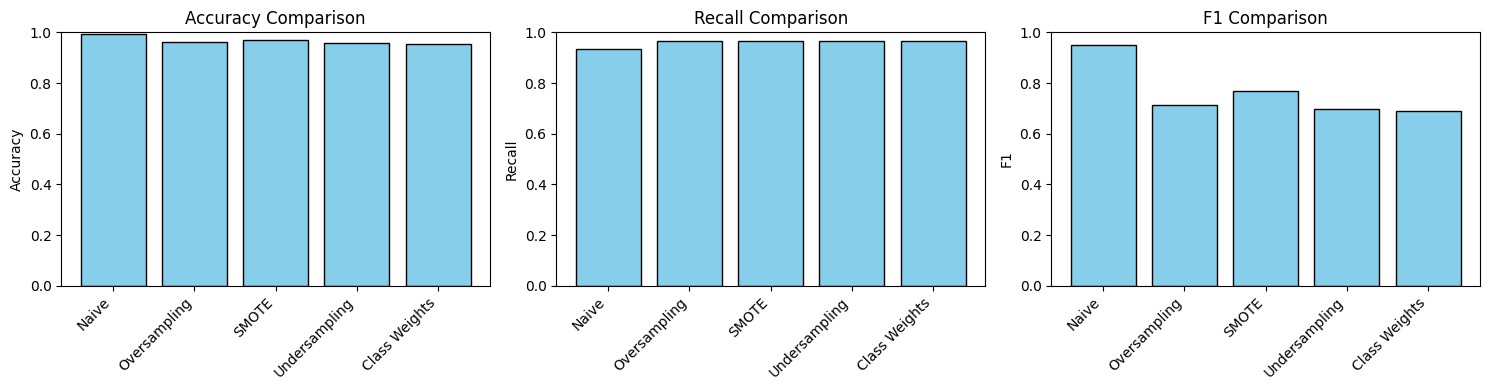

Notice: Recall (fraud detection) improved dramatically!


In [13]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['Accuracy', 'Recall', 'F1']
for i, metric in enumerate(metrics):
    axes[i].bar(df_results['Method'], df_results[metric], color='skyblue', edgecolor='black')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(df_results['Method'], rotation=45, ha='right')
    axes[i].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("Notice: Recall (fraud detection) improved dramatically!")

---
## 8. Proper Metrics for Imbalanced Data

In [14]:
# ❌ BAD: Accuracy
print("❌ Accuracy (misleading):")
print(f"   Naive:   {model_naive.score(X_test, y_test):.1%}")
print(f"   Weighted: {model_weighted.score(X_test, y_test):.1%}")
print("   Naive looks better! But misses all fraud.")

print("\n" + "="*50)

# ✅ GOOD: Precision, Recall, F1
print("✅ Better Metrics:")
print("\nPrecision: Of predicted fraud, how many are real?")
print(f"  Naive:   {precision_score(y_test, y_pred_naive):.1%}")
print(f"  Weighted: {precision_score(y_test, y_pred_weighted):.1%}")

print("\nRecall: Of all fraud, how many did we catch?")
print(f"  Naive:   {recall_score(y_test, y_pred_naive):.1%}  ← Terrible!")
print(f"  Weighted: {recall_score(y_test, y_pred_weighted):.1%}  ← Much better!")

print("\nF1: Harmonic mean of precision and recall")
print(f"  Naive:   {f1_score(y_test, y_pred_naive):.1%}")
print(f"  Weighted: {f1_score(y_test, y_pred_weighted):.1%}")

print("\n✅ For imbalanced data, optimize for:")
print("  - Fraud detection → Recall")
print("  - Spam filter → Precision")
print("  - Balanced → F1")

❌ Accuracy (misleading):
   Naive:   99.5%
   Weighted: 95.5%
   Naive looks better! But misses all fraud.

✅ Better Metrics:

Precision: Of predicted fraud, how many are real?
  Naive:   96.7%
  Weighted: 53.6%

Recall: Of all fraud, how many did we catch?
  Naive:   93.5%  ← Terrible!
  Weighted: 96.8%  ← Much better!

F1: Harmonic mean of precision and recall
  Naive:   95.1%
  Weighted: 69.0%

✅ For imbalanced data, optimize for:
  - Fraud detection → Recall
  - Spam filter → Precision
  - Balanced → F1


---
## Decision Tree: Which Method?

```
How imbalanced?
  < 60:40
    → No special handling needed
  
  60:40 to 90:10
    → Class Weights (easiest)
  
  > 90:10 (severe)
    ↓
    How much data?
      Small (<10k)
        → SMOTE (creates synthetic)
      
      Large (>100k)
        → Undersampling or Class Weights
      
      Huge (>1M)
        → Undersampling (faster training)
```

---
## Method Comparison

| Method | Pros | Cons | When to Use |
|--------|------|------|-------------|
| **Class Weights** | No resampling, fast | Model-dependent | First choice |
| **SMOTE** | Creates new samples | Slow on large data | Small-medium data |
| **Oversampling** | Simple | Risk overfitting | Quick baseline |
| **Undersampling** | Fast training | Lose information | Huge datasets |
| **Ensemble** | Best performance | Complex | Production systems |

---
## Key Takeaways

1. **Imbalanced data breaks naive models**
2. **Accuracy is MISLEADING** - use Precision/Recall/F1
3. **Class Weights** (easiest, try first)
4. **SMOTE** for small-medium datasets
5. **Undersampling** for huge datasets
6. **Always use stratified split**
7. **Focus on minority class metrics**

**Most common approach**: 
1. Try `class_weight='balanced'` first
2. If not enough, use SMOTE
3. Evaluate with F1 or Recall

---
## Your Turn

1. Create imbalanced dataset (90:10)
2. Train naive model, check confusion matrix
3. Try class weights
4. Try SMOTE
5. Compare Recall and F1

In [15]:
# Your code here